In [27]:
import os
import numpy as np
import pandas as pd
import scipy.io as sio
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, recall_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from IPython.display import clear_output
from sklearn.datasets import make_classification
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.metrics import confusion_matrix

Importiamo i dati e facciamo padding

In [28]:
data_dir = r'C:\Users\albic\OneDrive\Documenti\Immagini\Desktop\Machine learning\ECG_recording_local\training2017'  
target_len = 9000

ref = pd.read_csv(
    os.path.join(data_dir, r'C:\Users\albic\OneDrive\Documenti\Immagini\Desktop\Machine learning\ECG_recording_local\training2017\REFERENCE-original.csv'),
    header=None,
    names=['record', 'label']
)

def fix_length(v, target_len):
    v = np.squeeze(v)
    n = v.size

    if n == target_len:
        return v

    if n > target_len:
        # crop centrale (puoi scegliere anche dall'inizio: v[:target_len])
        start = (n - target_len) // 2
        return v[start:start + target_len]

    # n < target_len: padding con zeri in coda
    pad_width = target_len - n
    return np.pad(v, (0, pad_width))

signals = []
labels_s = []

for rec, lab in zip(ref['record'], ref['label']):
    mat_path = os.path.join(data_dir, rec + '.mat')
    if lab != '~' and lab != 'O':
        if not os.path.exists(mat_path):
            continue

        d = sio.loadmat(mat_path)
        v = d['val']   # (1, n) in generale

        v_fixed = fix_length(v, target_len)
        signals.append(v_fixed)
        labels_s.append(lab)
    

X = np.stack(signals, axis=0)   # (N_record, 9000)
y = np.stack(labels_s)


mapping = {'N': 0, 'A': 1}
y = np.array([mapping[lab] for lab in labels_s])


print(f"Dimensioni finali: X={X.shape}, y={y.shape}")

Dimensioni finali: X=(5925, 9000), y=(5925,)


Facciamo normalizzazione

In [29]:
def normalize_ecg(matrix):
    means = np.mean(matrix, axis=1, keepdims=True)
    stds = np.std(matrix, axis=1, keepdims=True)
    stds[stds == 0] = 1e-8 
    return (matrix - means) / stds

X_norm = normalize_ecg(X)

# 3. AGGIUNTA DIMENSIONE (Per Keras)
# X_ready = np.expand_dims(X_norm, axis=-1)

# 4. DIVISIONE 80/20 (Train e Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y  # Mantiene le proporzioni delle classi AFib e Normal!
)

f0=X_train[y_train == 0]
f1=X_train[y_train == 1]


# Ora estraiamo a caso da X_train per ottenere un train ridotto e bilanciato 50/50
indici = np.random.choice(f0.shape[0], size=617, replace=False)
X_train_reducted = f0[indici, :]


print(f"Dataset pronto! Dimensioni:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")
print(f"Numero di Normal nel training: {f0.shape}")
print(f"Numero di AF nel training: {f1.shape}")
print(f"Numero di Normal nel training ridotto: {X_train_reducted.shape}")

Dataset pronto! Dimensioni:
X_train: (4740, 9000)
y_train: (4740,)
X_test: (1185, 9000)
y_test: (1185,)
Numero di Normal nel training: (4123, 9000)
Numero di AF nel training: (617, 9000)
Numero di Normal nel training ridotto: (617, 9000)


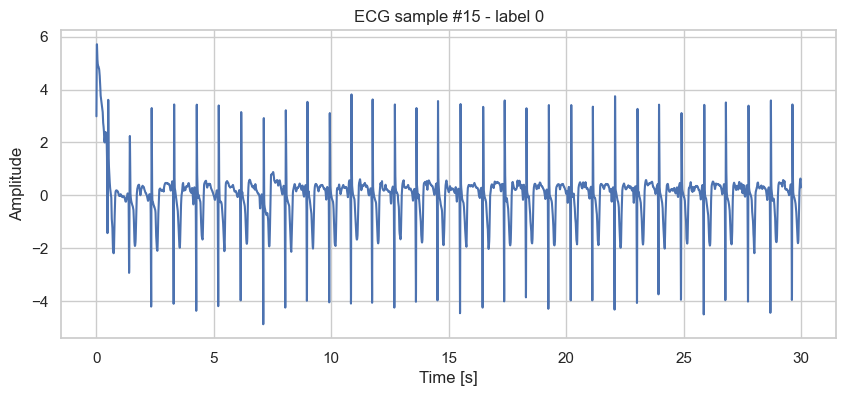

In [30]:
i = 15  # indice del record che si  vede
v = X_norm[i]
fs = 300
t = np.arange(v.size) / fs

plt.figure(figsize=(10, 4))
plt.plot(t, v)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title(f'ECG sample #{i} - label {y[i]}')
plt.grid(True)
plt.show()

Addestriamo un modello RandomForest che classifica Normal Vs AF su un dataset ridotto bilanciato 50/50

In [31]:
g0 = X_train_reducted  #Set di training ridotto
#g0 = X_train[y_train == 0]  #Tutte le righe dove y è 0 (Background)
g1 = X_train[y_train == 1]  #Tutte le righe dove y è 1 (Signal)


print(f"g0: {g0.shape}")
print(f"g1: {g1.shape}")

data0 = g0.astype(np.float64)
data1 = g1.astype(np.float64)

# --- Calcolo delle dimensioni (quante righe/campioni ci sono) ---

N0 = data0.shape[0]
N1 = data1.shape[0]

data = np.vstack([data0, data1])                # (N0+N1, 32*509)
labels = np.hstack((np.zeros(N0), np.ones(N1))) # np.hstack affianca un array di 0 e un array di 1

# --- Creiamo un array che va da 0 fino a (N0+N1 - 1) ---

original_indices = np.arange(N0 + N1)
NNeg = N0
NPos = N1

# --- Parametri di training ---

K = 5

rf_model = RandomForestClassifier(n_estimators=100, class_weight={0: 1, 1: 5}, n_jobs=-1)

skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=1)


acc_results = []  # array che ritorna accuracy per ogni fold
sens_results = [] # sensitivity
spec_results = [] # specificity

# --- Ciclo K-fold ---
print('--------------------')

fold_number = 1

for train_index, test_index in skf.split(data,labels):
    data_train, data_test = data[train_index], data[test_index]
    labels_train, labels_test = labels[train_index], labels[test_index]
    
    print(f"Fold {fold_number}")
    # fase di training
    rf_model.fit(data_train, labels_train)
    
    # fase di testing
    predictions = rf_model.predict(data_test)
    
    # confronta le previsioni con le soluzioni vere
    accuracy = accuracy_score(labels_test, predictions)
    sensitivity = recall_score(labels_test, predictions, pos_label=1)
    specificity = recall_score(labels_test, predictions, pos_label=0)
    
    acc_results.append(accuracy)
    sens_results.append(sensitivity)
    spec_results.append(specificity)
    
    #Printiamo per ogni fold
    print(f"Accuracy={accuracy*100:.2f}%,  Sensitivity={sensitivity*100:.2f}%, Specificity={specificity*100:.2f}%")
    fold_number +=1

# --- Calcolo Medie e Deviazioni Standard ---
acc_mean, acc_std = np.mean(acc_results)*100, np.std(acc_results)*100
sens_mean, sens_std = np.mean(sens_results)*100, np.std(sens_results)*100
spec_mean, spec_std = np.mean(spec_results)*100, np.std(spec_results)*100

print('--------------------')
print("Media sui K fold:")
print('--------------------')
print(f"Accuracy media = {np.mean(acc_results)*100:.2f}% ± {acc_std:.2f}%")
print(f"Sensitivity media = {np.mean(sens_results)*100:.2f}% ± {sens_std:.2f}%")
print(f"Specificity media = {np.mean(spec_results)*100:.2f}% ± {spec_std:.2f}%")
print('--------------------')


g0: (617, 9000)
g1: (617, 9000)
--------------------
Fold 1
Accuracy=48.99%,  Sensitivity=38.21%, Specificity=59.68%
Fold 2
Accuracy=51.42%,  Sensitivity=39.84%, Specificity=62.90%
Fold 3
Accuracy=52.63%,  Sensitivity=37.90%, Specificity=67.48%
Fold 4
Accuracy=47.37%,  Sensitivity=30.65%, Specificity=64.23%
Fold 5
Accuracy=51.22%,  Sensitivity=42.28%, Specificity=60.16%
--------------------
Media sui K fold:
--------------------
Accuracy media = 50.32% ± 1.89%
Sensitivity media = 37.77% ± 3.89%
Specificity media = 62.89% ± 2.85%
--------------------


Test con modello random forest

In [38]:
print("\n" + "="*50)
print("FASE DI EXTERNAL TEST")
print("="*50)

# --- 1. RIADDESTRAMENTO FINALE (Best Practice) ---
# Addestriamo il modello su TUTTO il dataset bilanciato (data, labels)
print("1. Riaddestramento del Random Forest su tutto il Training Set...")
rf_model.fit(data, labels)

# --- 2. PREDIZIONE SUL TEST SET ---
# A differenza delle reti neurali, il Random Forest sputa già fuori 0 o 1, 
# non serve mettere soglie ( > 0.5) o sigmoidi!
print("2. Valutazione sui pazienti mai visti (X_test)...")
predictions_test = rf_model.predict(X_test)

# Assicuriamoci che y_test sia un array piatto (1D) come piace a Scikit-Learn
y_test_flat = y_test.ravel()

# --- 3. CALCOLO DELLE METRICHE ---
accuracy_test = accuracy_score(y_test_flat, predictions_test)
sensitivity_test = recall_score(y_test_flat, predictions_test, pos_label=1)
specificity_test = recall_score(y_test_flat, predictions_test, pos_label=0)

# Calcoliamo la Matrice di Confusione in automatico
conf_matrix = confusion_matrix(y_test_flat, predictions_test)
# Scikit-Learn restituisce la matrice in questo ordine esatto:
TN, FP, FN, TP = conf_matrix.ravel()

# --- 4. STAMPA DEI RISULTATI ---
print("\n" + "=" * 40)
print("RISULTATI FINALI SUL TEST SET")
print("=" * 40)
print(f"Pazienti totali analizzati : {len(y_test_flat)}")
print(f"Accuracy Assoluta          : {accuracy_test * 100:.2f}%")
print(f"Sensitivity (Sui Malati)   : {sensitivity_test * 100:.2f}%")
print(f"Specificity (Sui Sani)     : {specificity_test * 100:.2f}%")
print("-" * 40)
print("MATRICE DI CONFUSIONE:")
print(f"Veri Positivi (TP): {TP}  | Falsi Positivi (FP): {FP}")
print(f"Falsi Negativi(FN): {FN}  | Veri Negativi (TN): {TN}")
print("=" * 40)

def permutation_p_value(y_true, y_pred, metric_fn, n_perm=1000, random_state=0):
    rng = np.random.default_rng(random_state)
    observed = metric_fn(y_true, y_pred)
    perm_values = []

    for _ in range(n_perm):
        y_perm = rng.permutation(y_true)
        perm_values.append(metric_fn(y_perm, y_pred))

    perm_values = np.array(perm_values)
    # p-value one-sided: P( M_perm >= M_obs | H0 )
    p_val = (np.sum(perm_values >= observed) + 1) / (n_perm + 1)
    return observed, p_val

obs_acc, p_val = permutation_p_value(
    y_true=y_test_flat,
    y_pred=predictions_test,
    metric_fn=accuracy_score,
    n_perm=1000,
    random_state=0
)

print("Observed accuracy:", obs_acc)
print("Permutation p-value:", p_val)


FASE DI EXTERNAL TEST
1. Riaddestramento del Random Forest su tutto il Training Set...
2. Valutazione sui pazienti mai visti (X_test)...

RISULTATI FINALI SUL TEST SET
Pazienti totali analizzati : 1185
Accuracy Assoluta          : 60.59%
Sensitivity (Sui Malati)   : 37.01%
Specificity (Sui Sani)     : 64.11%
----------------------------------------
MATRICE DI CONFUSIONE:
Veri Positivi (TP): 57  | Falsi Positivi (FP): 370
Falsi Negativi(FN): 97  | Veri Negativi (TN): 661
Observed accuracy: 0.6059071729957806
Permutation p-value: 0.41358641358641357


Accuracy vs Numero di variabili

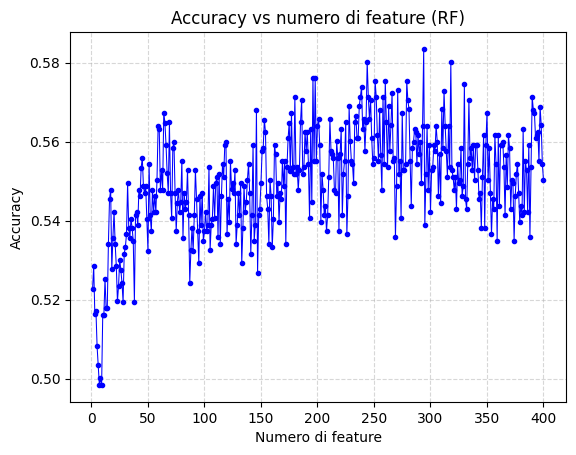

In [ ]:
NUMVAR = 400

acc_numvar = [] # array di accuracy in funzione di numvar

for numvar in range(1, NUMVAR +1):
    
    rf_model = RandomForestClassifier(class_weight={0: 1, 1: 5}, n_jobs=-1)

    
    acc_folds = []  # array di accuracy per un singolo fold
    
    for train_index, test_index in skf.split(data,labels):
        data_train, data_test = data[train_index, :numvar], data[test_index, :numvar]
        labels_train, labels_test = labels[train_index], labels[test_index]
        
        # fase di training
        rf_model.fit(data_train, labels_train)
        
        # fase di testing
        predictions = rf_model.predict(data_test)
        
        # confronta le previsioni con le soluzioni vere
        accuracy = accuracy_score(labels_test, predictions)
        
        # accuracy per questo fold
        acc_folds.append(accuracy)
        
    acc_numvar.append(np.mean(acc_folds))

# --- Plot accuracy vs numero di features ---

plt.figure()
plt.plot(np.arange(1, NUMVAR+1), acc_numvar, marker='o', color = 'b', markersize=3, linewidth=0.75)
plt.xlabel('Numero di feature')
plt.ylabel('Accuracy')
plt.title('Accuracy vs numero di feature (RF)')
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.show()

PCA RF

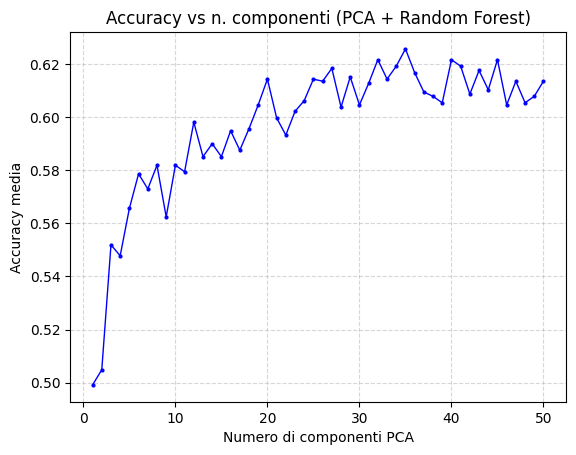

--------------------
MAX Accuracy:    62.56
MAX Sensitivity: 69.20
MAX Specificity: 55.90
Numero di componenti: 35
--------------------


In [ ]:
K = 5
NUMDIM = 50

skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=1)

acc_numdim = []   # array di accuracy in funzione di numvar = dimensione ridotta dei campioni tramite PCA
sens_numdim = []
spec_numdim = []

# --- Ciclo for su numvar = dimensione ridotta tramite PCA ---

for numdim in range(1, NUMDIM + 1):

    acc_folds = []   # array di accuracy per singolo fold
    sens_folds = []
    spec_folds = []

    for train_index, test_index in skf.split(data, labels):
        data_train, data_test = data[train_index], data[test_index]
        labels_train, labels_test = labels[train_index], labels[test_index]

        # PCA sul TRAIN (riduce a numvar componenti)
        pca = PCA(n_components = numdim)
        data_train_pca = pca.fit_transform(data_train)
        data_test_pca  = pca.transform(data_test) 

        rf_model = RandomForestClassifier(class_weight={0: 1, 1: 5}, n_jobs=-1)
        
        # training
        rf_model.fit(data_train_pca, labels_train)
        
        # testing 
        predictions = rf_model.predict(data_test_pca)
        
        # metriche per questo fold
        acc  = accuracy_score(labels_test, predictions)
        sens = recall_score(labels_test, predictions, pos_label=1)
        spec = recall_score(labels_test, predictions, pos_label=0)

        acc_folds.append(acc)
        sens_folds.append(sens)
        spec_folds.append(spec)
    
    # medie sui K fold per questo numvar
    acc_numdim.append(np.mean(acc_folds))
    sens_numdim.append(np.mean(sens_folds))
    spec_numdim.append(np.mean(spec_folds))
    

plt.figure()
plt.plot(np.arange(1, NUMDIM + 1), acc_numdim, marker='o', color='b', linewidth=1, markersize=2)
plt.xlabel('Numero di componenti PCA')
plt.ylabel('Accuracy media')
plt.title('Accuracy vs n. componenti (PCA + Random Forest)')
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.show()

# --- Risultati migliori ---
best_idx = int(np.argmax(acc_numdim))
best_numdim = best_idx + 1

print('--------------------')
print(f'MAX Accuracy:    {acc_numdim[best_idx]*100:.2f}')
print(f'MAX Sensitivity: {sens_numdim[best_idx]*100:.2f}')
print(f'MAX Specificity: {spec_numdim[best_idx]*100:.2f}')
print(f'Numero di componenti: {best_numdim}')
print('--------------------')

In [ ]:
pca_best = PCA(n_components=best_numdim)
data_pca = pca_best.fit_transform(data)

print('--------------------')
print(f'Numero ottimale di componenti: {best_numdim}')
print('--------------------')

# --- Varianza spiegata da ogni componente ---
print('Varianza spiegata da ogni componente')
print('--------------------')
print(pca_best.explained_variance_ratio_)
print('--------------------')

# --- Varianza cumulativa ---
print('Varianza cumulativa')
print('--------------------')

cumulative_variance = np.cumsum(pca_best.explained_variance_ratio_)
print(cumulative_variance)
print('--------------------')                       # primo autovettore

--------------------
Numero ottimale di componenti: 35
--------------------
Varianza spiegata da ogni componente
--------------------
[0.01428441 0.01380376 0.01069636 0.0097057  0.00894771 0.00844527
 0.00820425 0.0080545  0.00756666 0.00736465 0.00711549 0.00681777
 0.00653269 0.00636875 0.00624557 0.00613453 0.00598389 0.00586208
 0.00570858 0.00562817 0.00553344 0.0053642  0.00508963 0.00503454
 0.00501347 0.00498201 0.00478077 0.00474181 0.00473256 0.00464221
 0.00450065 0.00434924 0.00432146 0.0042057  0.00408339]
--------------------
Varianza cumulativa
--------------------
[0.01428441 0.02808817 0.03878453 0.04849023 0.05743794 0.06588322
 0.07408746 0.08214196 0.08970862 0.09707327 0.10418876 0.11100653
 0.11753922 0.12390797 0.13015354 0.13628807 0.14227197 0.14813405
 0.15384263 0.1594708  0.16500424 0.17036844 0.17545806 0.1804926
 0.18550607 0.19048808 0.19526885 0.20001066 0.20474322 0.20938543
 0.21388608 0.21823532 0.22255678 0.22676249 0.23084588]
--------------------


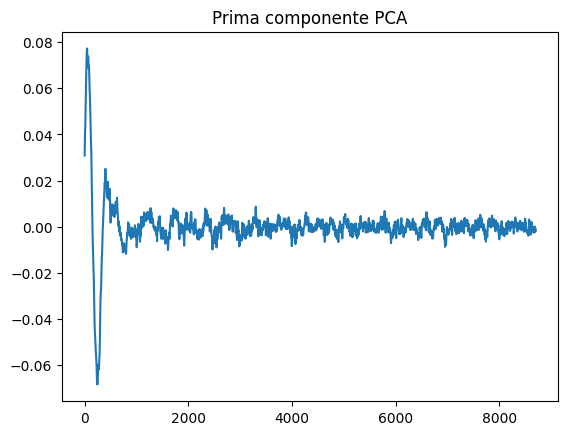

--------------------
Canali dei 20 coefficienti più grandi della prima componente principale: [46 45 44 47 43 48 42 49 41 50 40 51 39 68 52 67 69 38 70 66]
--------------------
Valori dei coefficienti: [0.07719893 0.07717655 0.07701173 0.07700341 0.07668589 0.07654968
 0.07615491 0.0759916  0.07553635 0.07528393 0.07489112 0.07449424
 0.07419793 0.07371715 0.07369739 0.07362375 0.07361779 0.07338676
 0.07336532 0.07330833]
--------------------


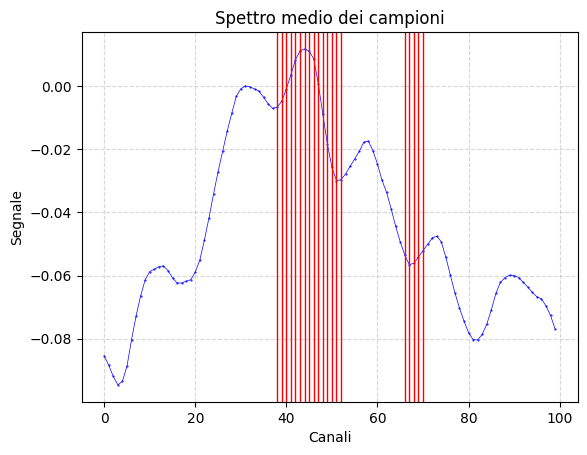

In [ ]:
# --- Autovettori (componenti principali) ---
U = pca_best.components_  # (best_numvar, n_feature_originali)


v1 = U[0]  # primo autovettore

plt.plot(v1)
plt.title('Prima componente PCA')
plt.show()



v1_ordered = np.argsort(v1)
indexes_max = v1_ordered[-20:][::-1]
ref.head()
print('--------------------')
print(f'Canali dei 20 coefficienti più grandi della prima componente principale: {indexes_max}')
print('--------------------')
print(f'Valori dei coefficienti: {v1[indexes_max]}')
print('--------------------')

# --- 

spectrum_sum = data.sum(axis=0)
spectrum_mean = data.sum(axis=0) / (N0+N1)

# --- Plottiamo nell'intorno dei canali corrispondenti ai massimi ---
x = np.arange(0,100)
plt.figure()
plt.plot(x, spectrum_mean[x], marker='o', markersize=0.5, color='b', linewidth=0.5)

for index in indexes_max:
    plt.axvline(x=index, color='r', linewidth=1)
plt.xlabel('Canali')
plt.ylabel('Segnale')
plt.title('Spettro medio dei campioni')
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.show()

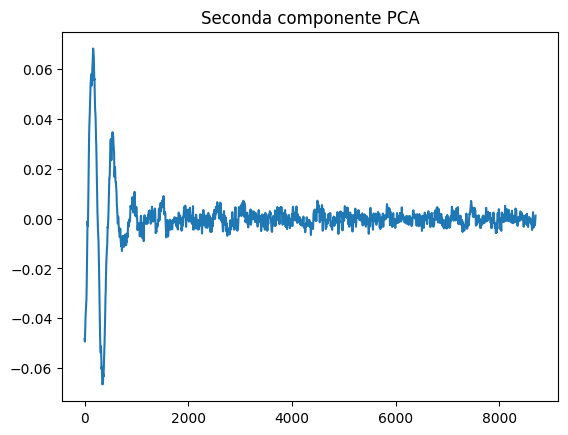

--------------------
Canali dei 5 coefficienti più grandi della prima componente principale: [164 163 165 166 162 167 161 168 160]
--------------------
Valori dei coefficienti: [0.06828997 0.06824807 0.06820752 0.06798536 0.06795155 0.06760862
 0.06755071 0.06721087 0.06698957]
--------------------


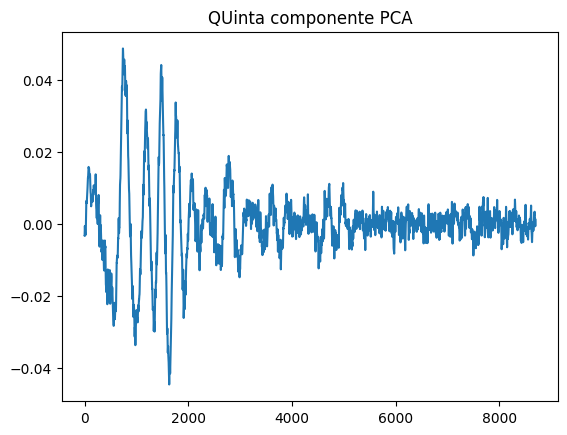

--------------------
Canali dei 5 coefficienti più grandi della prima componente principale: [741 742 743 740 744 739 745 746 738]
--------------------
Valori dei coefficienti: [0.04868083 0.04867551 0.04833281 0.04817342 0.04764041 0.04724766
 0.04678567 0.04608876 0.04606251]
--------------------


In [ ]:
v2 = U[1]  # primo autovettore
v5 = U[4]

plt.plot(v2)
plt.title('Seconda componente PCA')
plt.show()

v2_ordered = np.argsort(v2)
indexes_max_2 = v2_ordered[-9:][::-1]
ref.head()
print('--------------------')
print(f'Canali dei 5 coefficienti più grandi della prima componente principale: {indexes_max_2}')
print('--------------------')
print(f'Valori dei coefficienti: {v2[indexes_max_2]}')
print('--------------------')

plt.plot(v5)
plt.title('Quinta componente PCA')
plt.show()

# --- 

v5_ordered = np.argsort(v5)
indexes_max_5 = v5_ordered[-9:][::-1]
ref.head()
print('--------------------')
print(f'Canali dei 5 coefficienti più grandi della prima componente principale: {indexes_max_5}')
print('--------------------')
print(f'Valori dei coefficienti: {v5[indexes_max_5]}')
print('--------------------')

Fare un grid search per trovare i parametri migliori per un modello SVM

In [33]:

# 1. Creiamo la Pipeline esplicita
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC())
])

# 2. La Griglia dei Parametri 
param_grid = {
    'svm__C': [0.1, 1, 10, 100],             
    'svm__kernel': ['linear', 'rbf', 'poly', 'sigmoid'],    # Tipi di confini di decisione
    'svm__gamma': ['scale', 'auto']              # Importante per i kernel rbf e poly
}

# 3. Impostiamo il K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Inizializziamo il Grid Search
print("Inizio Grid Search...")
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=skf,               # Gli passiamo il tuo K-Fold a 5 split
    scoring='accuracy',   # Vogliamo trovare i parametri che massimizzano l'Accuracy
    n_jobs=-1,  
    verbose=2             # Stampa a schermo cosa sta facendo
)

# 5. Facciamo partire l'addestramento intensivo
grid_search.fit(data, labels)

# 6. Risultati Finali
print('\n' + '-'*40)
print("RICERCA COMPLETATA!")
print('-'*40)
print(f"Migliori Parametri Trovati:\n{grid_search.best_params_}")
print(f"Migliore Accuracy Media: {grid_search.best_score_ * 100:.2f}%")
print('-'*40)

# Il modello con i parametri perfetti è già pronto all'uso qui:
best_model = grid_search.best_estimator_

Inizio Grid Search...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

----------------------------------------
RICERCA COMPLETATA!
----------------------------------------
Migliori Parametri Trovati:
{'svm__C': 100, 'svm__gamma': 'scale', 'svm__kernel': 'sigmoid'}
Migliore Accuracy Media: 52.68%
----------------------------------------


Addestriamo un modello SVM che classifica Normal Vs AF su un dataset ridotto bilanciato 50/50

In [34]:
# --- Parametri di training ---

K = 5
#svm_model = SVC(kernel='linear')   # usiamo kernel lineare

svm_model = best_model

skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=False)

acc_results = []  # array che ritorna accuracy per ogni fold
sens_results = [] # sensitivity
spec_results = [] # specificity

# --- Ciclo K-fold ---
print('--------------------')

fold_number = 1

for train_index, test_index in skf.split(data,labels):
    data_train, data_test = data[train_index], data[test_index]
    labels_train, labels_test = labels[train_index], labels[test_index]
    
    # fase di training
    svm_model.fit(data_train, labels_train)
    
    # fase di testing
    predictions = svm_model.predict(data_test)
    
    # confronta le previsioni con le soluzioni vere
    accuracy = accuracy_score(labels_test, predictions)
    sensitivity = recall_score(labels_test, predictions, pos_label=1)
    specificity = recall_score(labels_test, predictions, pos_label=0)
    
    acc_results.append(accuracy)
    sens_results.append(sensitivity)
    spec_results.append(specificity)
    
    # stampiamo i risultati
    print(f"Fold {fold_number}:     "
          f"Accuracy = {accuracy * 100:.2f}%     "
          f"Sensitivity = {sensitivity * 100:.2f}%     "
          f"Specificity = {specificity * 100:.2f}%     ")
    
    fold_number +=1
    
# --- CALCOLO DEVIAZIONE STANDARD ---
acc_std = np.std(acc_results) * 100
sens_std = np.std(sens_results) * 100
spec_std = np.std(spec_results) * 100

print('--------------------')
print("Media sui K fold:")
print('--------------------')
print(f"Accuracy media = {np.mean(acc_results)*100:.2f}% ± {acc_std:.2f}%")
print(f"Sensitivity media = {np.mean(sens_results)*100:.2f}% ± {sens_std:.2f}%")
print(f"Specificity media = {np.mean(spec_results)*100:.2f}% ± {spec_std:.2f}%")
print('--------------------')
acc_results_all_channels = np.mean(acc_results)

--------------------
Fold 1:     Accuracy = 49.39%     Sensitivity = 45.53%     Specificity = 53.23%     
Fold 2:     Accuracy = 48.18%     Sensitivity = 41.46%     Specificity = 54.84%     
Fold 3:     Accuracy = 49.80%     Sensitivity = 53.23%     Specificity = 46.34%     
Fold 4:     Accuracy = 49.39%     Sensitivity = 44.35%     Specificity = 54.47%     
Fold 5:     Accuracy = 48.37%     Sensitivity = 48.78%     Specificity = 47.97%     
--------------------
Media sui K fold:
--------------------
Accuracy media = 49.03% ± 0.63%
Sensitivity media = 46.67% ± 4.03%
Specificity media = 51.37% ± 3.52%
--------------------


Test esterno per modello svm

In [37]:
print("FASE DI EXTERNAL TEST")
print("="*50)

# --- 1. RIADDESTRAMENTO FINALE (Best Practice) ---
# Addestriamo il modello su TUTTO il dataset bilanciato (data, labels)
print("1. Riaddestramento del Random Forest su tutto il Training Set...")
svm_model.fit(data, labels)

# --- 2. PREDIZIONE SUL TEST SET ---
# A differenza delle reti neurali, il Random Forest sputa già fuori 0 o 1, 
# non serve mettere soglie ( > 0.5) o sigmoidi!
print("2. Valutazione sui pazienti mai visti (X_test)...")
predictions_test = svm_model.predict(X_test)

# Assicuriamoci che y_test sia un array piatto (1D) come piace a Scikit-Learn
y_test_flat = y_test.ravel()

# --- 3. CALCOLO DELLE METRICHE ---
accuracy_test = accuracy_score(y_test_flat, predictions_test)
sensitivity_test = recall_score(y_test_flat, predictions_test, pos_label=1)
specificity_test = recall_score(y_test_flat, predictions_test, pos_label=0)

# Calcoliamo la Matrice di Confusione in automatico
conf_matrix = confusion_matrix(y_test_flat, predictions_test)
# Scikit-Learn restituisce la matrice in questo ordine esatto:
TN, FP, FN, TP = conf_matrix.ravel()


# --- 4. STAMPA DEI RISULTATI ---
print("\n" + "=" * 40)
print("RISULTATI FINALI SUL TEST SET")
print("=" * 40)
print(f"Pazienti totali analizzati : {len(y_test_flat)}")
print(f"Accuracy Assoluta          : {accuracy_test * 100:.2f}%")
print(f"Sensitivity (Sui Malati)   : {sensitivity_test * 100:.2f}%")
print(f"Specificity (Sui Sani)     : {specificity_test * 100:.2f}%")
print("-" * 40)
print("MATRICE DI CONFUSIONE:")
print(f"Veri Positivi (TP): {TP}  | Falsi Positivi (FP): {FP}")
print(f"Falsi Negativi(FN): {FN}  | Veri Negativi (TN): {TN}")
print("=" * 40)

def permutation_p_value(y_true, y_pred, metric_fn, n_perm=1000, random_state=0):
    rng = np.random.default_rng(random_state)
    observed = metric_fn(y_true, y_pred)
    perm_values = []

    for _ in range(n_perm):
        y_perm = rng.permutation(y_true)
        perm_values.append(metric_fn(y_perm, y_pred))

    perm_values = np.array(perm_values)
    # p-value one-sided: P( M_perm >= M_obs | H0 )
    p_val = (np.sum(perm_values >= observed) + 1) / (n_perm + 1)
    return observed, p_val

obs_acc, p_val = permutation_p_value(
    y_true=y_test_flat,
    y_pred=predictions_test,
    metric_fn=accuracy_score,
    n_perm=1000,
    random_state=0
)

print("Observed accuracy:", obs_acc)
print("Permutation p-value:", p_val)

FASE DI EXTERNAL TEST
1. Riaddestramento del Random Forest su tutto il Training Set...
2. Valutazione sui pazienti mai visti (X_test)...

RISULTATI FINALI SUL TEST SET
Pazienti totali analizzati : 1185
Accuracy Assoluta          : 47.59%
Sensitivity (Sui Malati)   : 54.55%
Specificity (Sui Sani)     : 46.56%
----------------------------------------
MATRICE DI CONFUSIONE:
Veri Positivi (TP): 84  | Falsi Positivi (FP): 551
Falsi Negativi(FN): 70  | Veri Negativi (TN): 480
Observed accuracy: 0.4759493670886076
Permutation p-value: 0.4155844155844156


Accuracy vs numero di feature

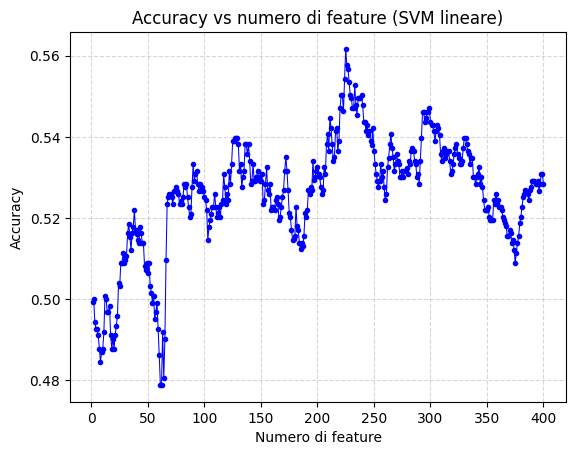

In [ ]:

NUMVAR = 400

acc_numvar = [] # array di accuracy in funzione di numvar

for numvar in range(1, NUMVAR +1):
    
    svm_model = best_model
    
    acc_folds = []  # array di accuracy per un singolo fold
    
    for train_index, test_index in skf.split(data,labels):
        data_train, data_test = data[train_index, :numvar], data[test_index, :numvar]
        labels_train, labels_test = labels[train_index], labels[test_index]
        
        # fase di training
        svm_model.fit(data_train, labels_train)
        
        # fase di testing
        predictions = svm_model.predict(data_test)
        
        # confronta le previsioni con le soluzioni vere
        accuracy = accuracy_score(labels_test, predictions)
        
        # accuracy per questo fold
        acc_folds.append(accuracy)
        
    acc_numvar.append(np.mean(acc_folds))

# --- Plot accuracy vs numero di features ---

plt.figure()
plt.plot(np.arange(1, NUMVAR+1), acc_numvar, marker='o', color = 'b', markersize=3, linewidth=0.75)
plt.xlabel('Numero di feature')
plt.ylabel('Accuracy')
plt.title('Accuracy vs numero di feature (SVM lineare)')
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.show()

PCA SVM

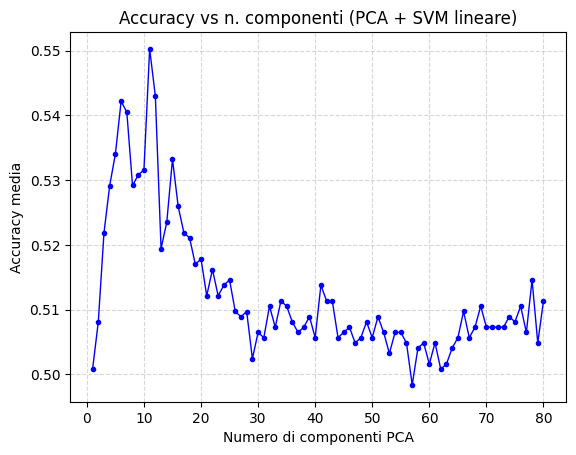

--------------------
MAX Accuracy:    55.03
MAX Sensitivity: 93.52
MAX Specificity: 16.53
Numero di componenti: 11
--------------------


In [ ]:
K = 5
NUMDIM = 80

skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=1)

acc_numdim = []   # array di accuracy in funzione di numvar = dimensione ridotta dei campioni tramite PCA
sens_numdim = []
spec_numdim = []

# --- Ciclo for su numvar = dimensione ridotta tramite PCA ---

for numdim in range(1, NUMDIM + 1):

    acc_folds = []   # array di accuracy per singolo fold
    sens_folds = []
    spec_folds = []

    for train_index, test_index in skf.split(data, labels):
        data_train, data_test = data[train_index], data[test_index]
        labels_train, labels_test = labels[train_index], labels[test_index]

        # PCA sul TRAIN (riduce a numvar componenti)
        pca = PCA(n_components = numdim)
        data_train_pca = pca.fit_transform(data_train)
        data_test_pca  = pca.transform(data_test) 

        # SVM lineare
        svm_model = best_model

        # training
        svm_model.fit(data_train_pca, labels_train)
        
        # testing 
        predictions = svm_model.predict(data_test_pca)
        
        # metriche per questo fold
        acc  = accuracy_score(labels_test, predictions)
        sens = recall_score(labels_test, predictions, pos_label=1)
        spec = recall_score(labels_test, predictions, pos_label=0)

        acc_folds.append(acc)
        sens_folds.append(sens)
        spec_folds.append(spec)
    
    # medie sui K fold per questo numvar
    acc_numdim.append(np.mean(acc_folds))
    sens_numdim.append(np.mean(sens_folds))
    spec_numdim.append(np.mean(spec_folds))
    

plt.figure()
plt.plot(np.arange(1, NUMDIM + 1), acc_numdim, marker='o', color='b', linewidth=1, markersize=3)
plt.xlabel('Numero di componenti PCA')
plt.ylabel('Accuracy media')
plt.title('Accuracy vs n. componenti (PCA + SVM lineare)')
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.show()

# --- Risultati migliori ---
best_idx = int(np.argmax(acc_numdim))
best_numdim = best_idx + 1

print('--------------------')
print(f'MAX Accuracy:    {acc_numdim[best_idx]*100:.2f}')
print(f'MAX Sensitivity: {sens_numdim[best_idx]*100:.2f}')
print(f'MAX Specificity: {spec_numdim[best_idx]*100:.2f}')
print(f'Numero di componenti: {best_numdim}')
print('--------------------')

In [ ]:
pca_best = PCA(n_components=best_numdim)
data_pca = pca_best.fit_transform(data)

print('--------------------')
print(f'Numero ottimale di componenti: {best_numdim}')
print('--------------------')

# --- Varianza spiegata da ogni componente ---
print('Varianza spiegata da ogni componente')
print('--------------------')
print(pca_best.explained_variance_ratio_)
print('--------------------')

# --- Varianza cumulativa ---
print('Varianza cumulativa')
print('--------------------')

cumulative_variance = np.cumsum(pca_best.explained_variance_ratio_)
print(cumulative_variance)
print('--------------------')                       # primo autovettore 

--------------------
Numero ottimale di componenti: 11
--------------------
Varianza spiegata da ogni componente
--------------------
[0.01428441 0.01380374 0.01069618 0.00970549 0.00894566 0.0084423
 0.00820192 0.00805256 0.00756059 0.00732905 0.00709451]
--------------------
Varianza cumulativa
--------------------
[0.01428441 0.02808815 0.03878432 0.04848981 0.05743547 0.06587777
 0.07407969 0.08213225 0.08969283 0.09702188 0.10411638]
--------------------


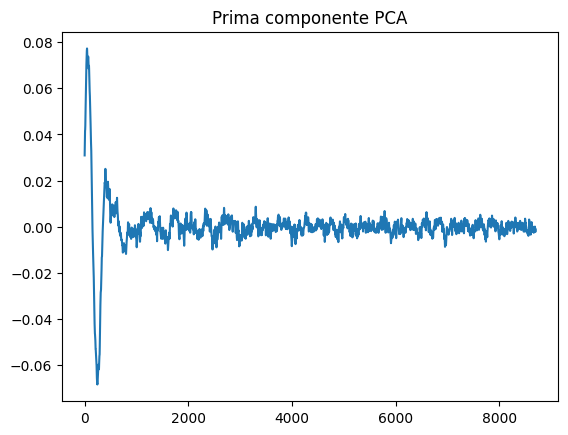

--------------------
Canali dei 5 coefficienti più grandi della prima componente principale: [46 45 44 47 43 48 42 49 41]
--------------------
Valori dei coefficienti: [0.07721315 0.07719144 0.07702747 0.07701721 0.07670274 0.07656345
 0.07617297 0.07600562 0.07555555]
--------------------


In [ ]:
# --- Autovettori (componenti principali) ---
U = pca_best.components_  # (best_numvar, n_feature_originali)


v1 = U[0]  # primo autovettore

plt.plot(v1)
plt.title('Prima componente PCA')
plt.show()

# Canali corrispondenti ai primi 9 massimi della prima componente principale
v1_ordered = np.argsort(v1)
indexes_max = v1_ordered[-9:][::-1]
print('--------------------')
print(f'Canali dei 5 coefficienti più grandi della prima componente principale: {indexes_max}')
print('--------------------')
print(f'Valori dei coefficienti: {v1[indexes_max]}')
print('--------------------')

Grid search per rete neurale

In [ ]:
# --- 1. SETUP VARIABILI ---
# Assicuriamoci che le label siano colonne
labels = labels.reshape(-1, 1)
labels_flat = labels.ravel()

# Definiamo la nostra griglia di ricerca
griglia_learning_rates = [0.03, 0.01, 0.005, 0.001]
griglia_epochs = [20, 50, 100, 300]

# Prepariamo lo strumento K-Fold (dividiamo i dati in 5 fette)
k = 5
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

# Variabili per salvare il "campione"
miglior_accuracy_media = 0.0
migliori_parametri = {}

print("-" * 50)

# --- 2. CICLI DELLA GRID SEARCH E DEL K-FOLD ---
for lr in griglia_learning_rates:
    for epoche in griglia_epochs:
        
        # Lista per salvare i voti (accuracy) dei 5 esami di questa combinazione
        fold_accuracies = []
        
        # Inizia la rotazione del K-Fold!
        # kf.split() ci restituisce in automatico le righe da usare per Train e Validazione
        for train_index, val_index in skf.split(data, labels_flat):
            
            # Estraiamo fisicamente le matrici per questo specifico round
            X_fold_train, X_fold_val = data[train_index], data[val_index]
            y_fold_train, y_fold_val = labels[train_index], labels[val_index]
            m_fold = X_fold_train.shape[0]
            
            # [FONDAMENTALE] Resettiamo il cervello della rete ad ogni singolo fold!
            np.random.seed(42)
            W = np.random.randn(data.shape[1], 1) * 0.01 
            b = 0.0 
            
            # --- A. ADDESTRAMENTO (Sulle 4 fette di Train) ---
            for epoch in range(epoche):
                # Forward
                Z = np.dot(X_fold_train, W) + b
                A = 1 / (1 + np.exp(-Z)) 
                
                # Backward (con derivata MSE parabolica)
                dA = 2 * (A - y_fold_train)
                dZ = dA * A * (1 - A)
                dW = (1 / m_fold) * np.dot(X_fold_train.T, dZ)
                db = (1 / m_fold) * np.sum(dZ)
                
                # Aggiornamento SGD
                W = W - lr * dW
                b = b - lr * db
                
            # --- B. VALIDAZIONE (Sulla fetta tenuta da parte) ---
            Z_val = np.dot(X_fold_val, W) + b
            A_val = 1 / (1 + np.exp(-Z_val)) 
            predizioni = np.where(A_val > 0.5, 1, 0)
            
            corrette = np.sum(predizioni == y_fold_val)
            accuracy_fold = (corrette / len(y_fold_val)) * 100
            
            # Salviamo l'esito di questa fetta
            fold_accuracies.append(accuracy_fold)
            
        # --- C. VALUTAZIONE COMBINAZIONE ---
        # Finiti i 5 fold, calcoliamo la vera Accuracy di questa combinazione (la media)
        accuracy_media = np.mean(fold_accuracies)
        print(f"LR: {lr} | Epoche: {epoche} -> Accuracy Media: {accuracy_media:.2f}%")
        
        # Se ha battuto il record, la salviamo
        if accuracy_media > miglior_accuracy_media:
            miglior_accuracy_media = accuracy_media
            migliori_parametri = {'learning_rate': lr, 'epochs': epoche}

# --- 3. RISULTATO DELLA RICERCA ---
print("\n" + "=" * 50)
print(" MIGLIORI IPERPARAMETRI TROVATI ")
print("=" * 50)
print(f"Learning Rate ottimale : {migliori_parametri['learning_rate']}")
print(f"Epoche ottimale        : {migliori_parametri['epochs']}")
print(f"Accuracy migliore       : {miglior_accuracy_media:.2f}%")
print("=" * 50)

--------------------------------------------------
LR: 0.03 | Epoche: 20 -> Accuracy Media: 49.44%
LR: 0.03 | Epoche: 50 -> Accuracy Media: 49.27%
LR: 0.03 | Epoche: 100 -> Accuracy Media: 49.68%
LR: 0.03 | Epoche: 300 -> Accuracy Media: 49.60%
LR: 0.01 | Epoche: 20 -> Accuracy Media: 50.97%
LR: 0.01 | Epoche: 50 -> Accuracy Media: 50.73%
LR: 0.01 | Epoche: 100 -> Accuracy Media: 49.84%
LR: 0.01 | Epoche: 300 -> Accuracy Media: 49.76%
LR: 0.005 | Epoche: 20 -> Accuracy Media: 51.62%
LR: 0.005 | Epoche: 50 -> Accuracy Media: 50.89%
LR: 0.005 | Epoche: 100 -> Accuracy Media: 50.73%
LR: 0.005 | Epoche: 300 -> Accuracy Media: 49.35%
LR: 0.001 | Epoche: 20 -> Accuracy Media: 52.51%
LR: 0.001 | Epoche: 50 -> Accuracy Media: 52.76%
LR: 0.001 | Epoche: 100 -> Accuracy Media: 51.54%
LR: 0.001 | Epoche: 300 -> Accuracy Media: 50.89%

 MIGLIORI IPERPARAMETRI TROVATI 
Learning Rate ottimale : 0.001
Epoche ottimale        : 50
Accuracy migliore       : 52.76%


Rete neurale

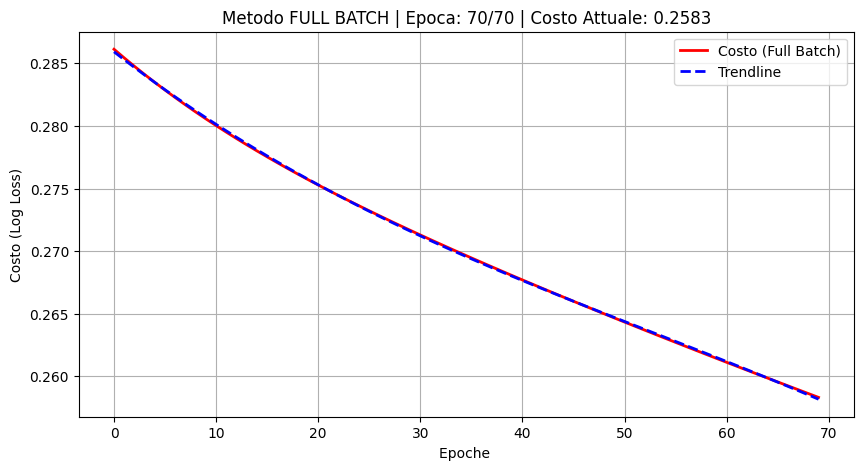

In [ ]:
#  1. INIZIALIZZAZIONE PARAMETRI 
# Trasforma y_train da array piatto a colonna 
labels = labels.reshape(-1, 1)

np.random.seed(42)
W = np.random.randn(data.shape[1], 1) * 0.01 
b = 0.0                                   

#  2. IPERPARAMETRI 
epochs = 70
learning_rate = 0.001
storia_costo = [] 

#  3. CICLO DI ADDESTRAMENTO (FULL BATCH) 
m = data.shape[0] # Il numero totale di pazienti

for epoch in range(epochs):
    
    # Shuffle dei dati di training ad ogni epoca
    indici = np.random.permutation(data.shape[0])
    X_shuffled = data[indici]
    y_shuffled = labels[indici] # usa la tua y_train binarizzata

    #  FORWARD PROPAGATION 
    Z = np.dot(X_shuffled, W) + b
    A = 1 / (1 + np.exp(-Z)) # Sigmoide
    
   
    #  FUNZIONE DI COSTO (Mean Squared Error) 
    costo = np.mean((A - y_shuffled) ** 2)
    storia_costo.append(costo)
        
    # -- BACKWARD PROPAGATION 
    dA = 2 * (A - y_shuffled)
        
    # 2. Derivata della Sigmoide: A * (1 - A)
    dZ = dA * A * (1 - A)
        
    # 3. Aggiornamento Pesi e Bias
    dW = (1 / m) * np.dot(X_shuffled.T, dZ)
    db = (1 / m) * np.sum(dZ)

    
    #  AGGIORNAMENTO PESI (SGD classico) 
    W = W - learning_rate * dW
    b = b - learning_rate * db
    
    #  PLOT IN TEMPO REALE 
    if epoch % 10 == 0 or epoch == epochs - 1: 
        clear_output(wait=True)
        plt.figure(figsize=(10, 5))
        
        # 1. Plot dei dati grezzi
        plt.plot(storia_costo, color='red', linewidth=2, label='Costo (Full Batch)')
        
        # 2. FIT DELL'ERRORE 
        # (Con il Full Batch la linea rossa sarà già molto liscia perché non c'è il rumore dei piccoli batch,
        # ma manteniamo la linea di tendenza blu per estetica)
        if len(storia_costo) > 10:
            asse_x = np.arange(len(storia_costo)) 
            coefficienti = np.polyfit(asse_x, storia_costo, 3)
            polinomio = np.poly1d(coefficienti)
            plt.plot(asse_x, polinomio(asse_x), color='blue', linewidth=2, linestyle='--', label='Trendline')
        
        # 3. Dettagli del grafico
        plt.title(f"Metodo FULL BATCH | Epoca: {epoch+1}/{epochs} | Costo Attuale: {costo:.4f}")
        plt.xlabel("Epoche ")
        plt.ylabel("Costo (Log Loss)")
        plt.legend()
        plt.grid(True)
        plt.show()

Testing rete neurale

In [ ]:
# TEST 

y_test = y_test.reshape(-1, 1)

# 1. FORWARD PROPAGATION SUL TEST SET
# Usiamo la W e la b definitive per calcolare la Z
Z_test = np.dot(X_test, W) + b

# Passiamo tutto nella Sigmoide
A_test = 1 / (1 + np.exp(-Z_test)) 

# 2. TRASFORMIAMO LE PROBABILITÀ IN PREVISIONI(0 o 1)
# Se la probabilità è maggiore del 50% (0.5), il paziente è 1 (Anomalo)
# Se è minore, il paziente è 0 (Sano)
predizioni = np.where(A_test > 0.5, 1, 0)

# 3. CALCOLO DELL'ACCURACY
corrette = np.sum(predizioni == y_test)
totali = len(y_test)
accuracy = (corrette / totali) * 100

# 4. CALCOLO SENSITIVITY E SPECIFICITY

# Troviamo i TP, TN, FP, FN confrontando le predizioni con la verità
# usiamo l'operatore '&' per verificare due condizioni contemporaneamente in NumPy
TP = np.sum((predizioni == 1) & (y_test == 1))
TN = np.sum((predizioni == 0) & (y_test == 0))
FP = np.sum((predizioni == 1) & (y_test == 0))
FN = np.sum((predizioni == 0) & (y_test == 1))


sensitivity = (TP / (TP + FN)) * 100 if (TP + FN) > 0 else 0.0

specificity = (TN / (TN + FP)) * 100 if (TN + FP) > 0 else 0.0

# Stampiamo i risultati
print(f"Esame completato su {totali} pazienti!")
print(f"Risposte corrette: {corrette}")
print(f"Accuracy finale: {accuracy:.2f}%")
print("-" * 30)
print("MATRICE DI CONFUSIONE:")
print(f"Veri Positivi (TP): {TP}  | Falsi Positivi (FP): {FP}")
print(f"Falsi Negativi(FN): {FN}  | Veri Negativi (TN): {TN}")
print("-" * 30)
print(f"Sensitivity (Capacità di trovare i malati): {sensitivity:.2f}%")
print(f"Specificity (Capacità di riconoscere i sani): {specificity:.2f}%")


Esame completato su 1185 pazienti!
Risposte corrette: 574
Accuracy finale: 48.44%
------------------------------
MATRICE DI CONFUSIONE:
Veri Positivi (TP): 80  | Falsi Positivi (FP): 537
Falsi Negativi(FN): 74  | Veri Negativi (TN): 494
------------------------------
Sensitivity (Capacità di trovare i malati): 51.95%
Specificity (Capacità di riconoscere i sani): 47.91%


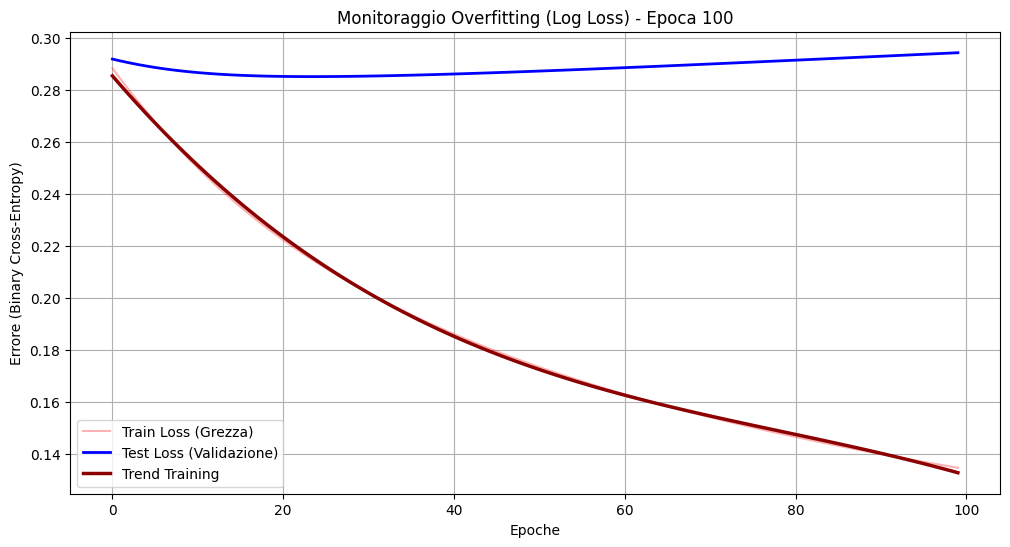

In [ ]:
# 1. INIZIALIZZAZIONE PARAMETRI
# Trasforma y_train da array piatto (4740,) a colonna (4740, 1)
labels = labels.reshape(-1, 1)
np.random.seed(42)
W = np.random.randn(X_train.shape[1], 1) * 0.01 
b = 0.0


#  2. IPERPARAMETRI 
epochs = 100
learning_rate = 0.01
m = data.shape[0] # Il numero totale di pazienti

# --- NUOVE LISTE PER IL MONITORAGGIO ---
storia_costo_train = []
storia_costo_test = []
iterazione_totale = 0

for epoch in range(epochs):
    # Shuffle dei dati di training ad ogni epoca
    indici = np.random.permutation(data.shape[0])
    X_shuffled = data[indici]
    y_shuffled = labels[indici] # usa la tua y_train binarizzata
    

        # 2. FORWARD PROPAGATION (Training)
    Z = np.dot(X_shuffled, W) + b
    A = 1 / (1 + np.exp(-Z))
        
    # 3. CALCOLO COSTO TRAINING (Binary Cross-Entropy)
    costo_t = np.mean((A - y_shuffled) ** 2)
    storia_costo_train.append(costo_t)
        
    # 4. CALCOLO COSTO TEST (Binary Cross-Entropy)
    # Facciamo una "finta" previsione sui dati di test per vedere come va
    A_val = 1 / (1 + np.exp(-(np.dot(X_test, W) + b)))
    costo_v = np.mean((A_val - y_test) ** 2)
    storia_costo_test.append(costo_v)
        
    # 5. BACKWARD PROPAGATION E AGGIORNAMENTO
    dA = 2 * (A - y_shuffled)
    dZ = dA * A * (1 - A)
    dW = (1/m) * np.dot(X_shuffled.T, dZ)
    db = (1/m) * np.sum(dZ)
  
        
    W = W - learning_rate * dW
    b = b - learning_rate * db
        
    # 6. PLOT COMPARATIVO IN TEMPO REALE
    iterazione_totale += 1
    if iterazione_totale % 5 == 0: # Aggiorna ogni 5 batch
        clear_output(wait=True)
        plt.figure(figsize=(12, 6))
            
        # Linea Rossa: Training (quello che la rete "studia")
        plt.plot(storia_costo_train, color='red', alpha=0.3, label='Train Loss (Grezza)')
            
        # Linea Blu: Test (l'esame a sorpresa)
        plt.plot(storia_costo_test, color='blue', linewidth=2, label='Test Loss (Validazione)')
            
        # Trendline del training per pulizia visiva
        if len(storia_costo_train) > 10:
            x_idx = np.arange(len(storia_costo_train))
            fit = np.poly1d(np.polyfit(x_idx, storia_costo_train, 3))
            plt.plot(x_idx, fit(x_idx), color='darkred', linewidth=2.5, label='Trend Training')

            plt.title(f"Monitoraggio Overfitting (Log Loss) - Epoca {epoch+1}")
            plt.xlabel("Epoche")
            plt.ylabel("Errore (Binary Cross-Entropy)")
            plt.legend()
            plt.grid(True)
            plt.show()

Rete neurale con Torch

Epoca 0/20 | Costo (MSE): 25.1700
Epoca 1/20 | Costo (MSE): 22.1075
Epoca 2/20 | Costo (MSE): 19.1223
Epoca 3/20 | Costo (MSE): 16.2616
Epoca 4/20 | Costo (MSE): 13.5873
Epoca 5/20 | Costo (MSE): 11.1493
Epoca 6/20 | Costo (MSE): 8.9868
Epoca 7/20 | Costo (MSE): 7.1188
Epoca 8/20 | Costo (MSE): 5.5359
Epoca 9/20 | Costo (MSE): 4.2260
Epoca 10/20 | Costo (MSE): 3.1702
Epoca 11/20 | Costo (MSE): 2.3414
Epoca 12/20 | Costo (MSE): 1.7073
Epoca 13/20 | Costo (MSE): 1.2343
Epoca 14/20 | Costo (MSE): 0.8863
Epoca 15/20 | Costo (MSE): 0.6341
Epoca 16/20 | Costo (MSE): 0.4536
Epoca 17/20 | Costo (MSE): 0.3252
Epoca 18/20 | Costo (MSE): 0.2345
Epoca 19/20 | Costo (MSE): 0.1707


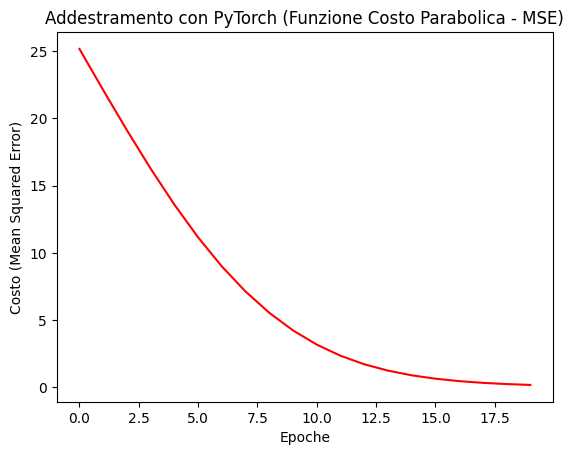

In [ ]:
# 1. PREPARAZIONE DATI 
X_tensor = torch.FloatTensor(data)
# labels deve essere messa in verticale
y_tensor = torch.FloatTensor(labels).reshape(-1, 1)

# 2. COSTRUZIONE RETE NEURALE 
# Definizione della Rete Neurale come classe
class ReteECG_Profonda(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        # Primo livello nascosto: da 8700 feature a 64 neuroni
        self.livello1 = nn.Linear(num_features, 64)
        self.attivazione1 = nn.ReLU() # Una nuova funzione di attivazione!
        
        # Secondo livello nascosto: da 64 a 32 neuroni
        self.livello2 = nn.Linear(64, 32)
        self.attivazione2 = nn.ReLU()
        
        # Livello finale (Il "Primario"): da 32 a 1 neurone
        self.livello_finale = nn.Linear(32, 1)
        self.sigmoide = nn.Sigmoid()
        
    # Definizione del passaggio Forward (da X ad A)
    def forward(self, x):
        # 1. Il paziente entra nel primo livello
        out = self.livello1(x)
        out = self.attivazione1(out)
        
        # 2. I risultati passano al secondo livello
        out = self.livello2(out)
        out = self.attivazione2(out)
        
        # 3. I risultati arrivano al primario per la diagnosi finale
        out = self.livello_finale(out)
        A = self.sigmoide(out)
        
        return A

# Creazione dell'istanza del modello, passandogli il numero di feature
modello = ReteECG_Profonda(data.shape[1])

# 3. COSTO E OTTIMIZZATORE 
criterio = nn.MSELoss()    

# L'ottimizzatore Adam si occupa di aggiornare i pesi (W e b) automaticamente
ottimizzatore = optim.Adam(modello.parameters(), lr=0.001)

storia_costo = []

# 4. CICLO DI ADDESTRAMENTO 
epochs = 20
for epoch in range(epochs):
    # FORWARD PROPAGATION 
    # Calcoliamo le predizioni A per tutto il dataset X contemporaneamente
    predizioni = modello(X_tensor)
    
    # CALCOLO COSTO (MSE) 
    # Calcoliamo l'errore quadratico medio attuale
    costo = criterio(predizioni, y_tensor)*100
    # Salviamo il valore del costo per il grafico
    storia_costo.append(costo.item())
    
    # BACKWARD PROPAGATION 
    # Pulisce i gradienti calcolati nell'epoca precedente
    ottimizzatore.zero_grad() 
    # Calcola automaticamente i gradienti (dW, db) usando l'MSE
    costo.backward()          
    # Aggiorna i pesi (W, b) usando l'Adam optimizer: W = W - lr * gradienti
    ottimizzatore.step()      
    
    # Stampa l'andamento ogni 50 epoche
    if epoch % 1 == 0:
        print(f'Epoca {epoch}/{epochs} | Costo (MSE): {costo.item():.4f}')

# --- 5. PLOT FINALE ---
# Plot finale dell'andamento del costo
plt.plot(storia_costo, color='red')
plt.title("Addestramento con PyTorch (Funzione Costo Parabolica - MSE)")
plt.xlabel("Epoche")
plt.ylabel("Costo (Mean Squared Error)")
plt.show()

Test con rete pytorch

Area Under Precision-Recall Curve (AUPRC): 0.1506


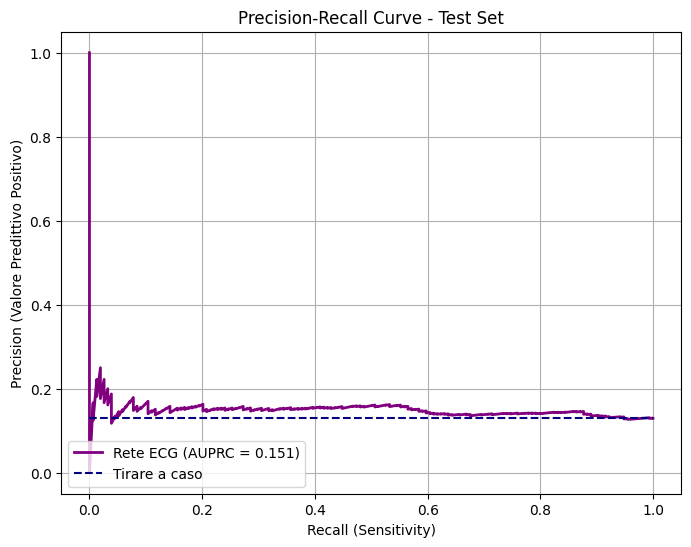

Esame PyTorch completato su 1185 pazienti!
Accuracy finale: 57.64%
------------------------------
MATRICE DI CONFUSIONE:
Veri Positivi (TP): 82  | Falsi Positivi (FP): 430
Falsi Negativi(FN): 72  | Veri Negativi (TN): 601
------------------------------
Sensitivity: 53.25%
Specificity: 58.29%


In [ ]:
# --- FASE DI EXTERNAL TEST CON PYTORCH ---

# 1. Trasformiamo anche i dati di Test in Tensori PyTorch
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).reshape(-1, 1)

# 2. "Posa la penna": Mettiamo il modello in modalità Esame
modello.eval()

# 3. Spegniamo il motore dei gradienti per risparmiare memoria
with torch.no_grad():
    
    # Facciamo la previsione su tutto il Test Set in un colpo solo
    A_test = modello(X_test_tensor)
    
    # Trasformiamo le probabilità (> 0.5) in 1 e 0
    # .float() converte il risultato Vero/Falso in 1.0 e 0.0
    predizioni_tensor = (A_test > 0.5).float()

probabilita_numpy = A_test.numpy() 
y_test_numpy = y_test_tensor.numpy()

# 2. CALCOLO AUPRC (In scikit-learn si chiama spesso Average Precision)
# FONDAMENTALE: passiamo le probabilità (probabilita_numpy), NON le predizioni (0 o 1)!
auprc = average_precision_score(y_test_numpy, probabilita_numpy)

print(f"Area Under Precision-Recall Curve (AUPRC): {auprc:.4f}")

# ==========================================
# 3. BONUS: DISEGNAMO LA CURVA!
# ==========================================
# Calcoliamo tutti i punti della curva
precision, recall, soglie = precision_recall_curve(y_test_numpy, probabilita_numpy)

# Creiamo il grafico
plt.figure(figsize=(8, 6))
# Disegniamo la linea della nostra rete
plt.plot(recall, precision, color='purple', linewidth=2, label=f'Rete ECG (AUPRC = {auprc:.3f})')

# Disegniamo la linea di un modello "stupido" che tira a caso (basata sulla % di malati)
percentuale_malati = np.sum(y_test_numpy == 1) / len(y_test_numpy)
plt.plot([0, 1], [percentuale_malati, percentuale_malati], color='navy', linestyle='--', label='Tirare a caso')

# Dettagli estetici
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (Valore Predittivo Positivo)')
plt.title('Precision-Recall Curve - Test Set')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

# 4. Ritorniamo nel mondo di NumPy per calcolare le metriche comodamente!
# Usiamo .numpy() per ritrasformare il Tensore in un array classico
predizioni = predizioni_tensor.numpy()
y_test_numpy = y_test_tensor.numpy()

# --- CALCOLO METRICHE (Esattamente identico a prima!) ---
corrette = np.sum(predizioni == y_test_numpy)
totali = len(y_test_numpy)
accuracy = (corrette / totali) * 100

TP = np.sum((predizioni == 1) & (y_test_numpy == 1))
TN = np.sum((predizioni == 0) & (y_test_numpy == 0))
FP = np.sum((predizioni == 1) & (y_test_numpy == 0))
FN = np.sum((predizioni == 0) & (y_test_numpy == 1))

sensitivity = (TP / (TP + FN)) * 100 if (TP + FN) > 0 else 0.0
specificity = (TN / (TN + FP)) * 100 if (TN + FP) > 0 else 0.0

# --- STAMPA RISULTATI ---
print(f"Esame PyTorch completato su {totali} pazienti!")
print(f"Accuracy finale: {accuracy:.2f}%")
print("-" * 30)
print("MATRICE DI CONFUSIONE:")
print(f"Veri Positivi (TP): {TP}  | Falsi Positivi (FP): {FP}")
print(f"Falsi Negativi(FN): {FN}  | Veri Negativi (TN): {TN}")
print("-" * 30)
print(f"Sensitivity: {sensitivity:.2f}%")
print(f"Specificity: {specificity:.2f}%")

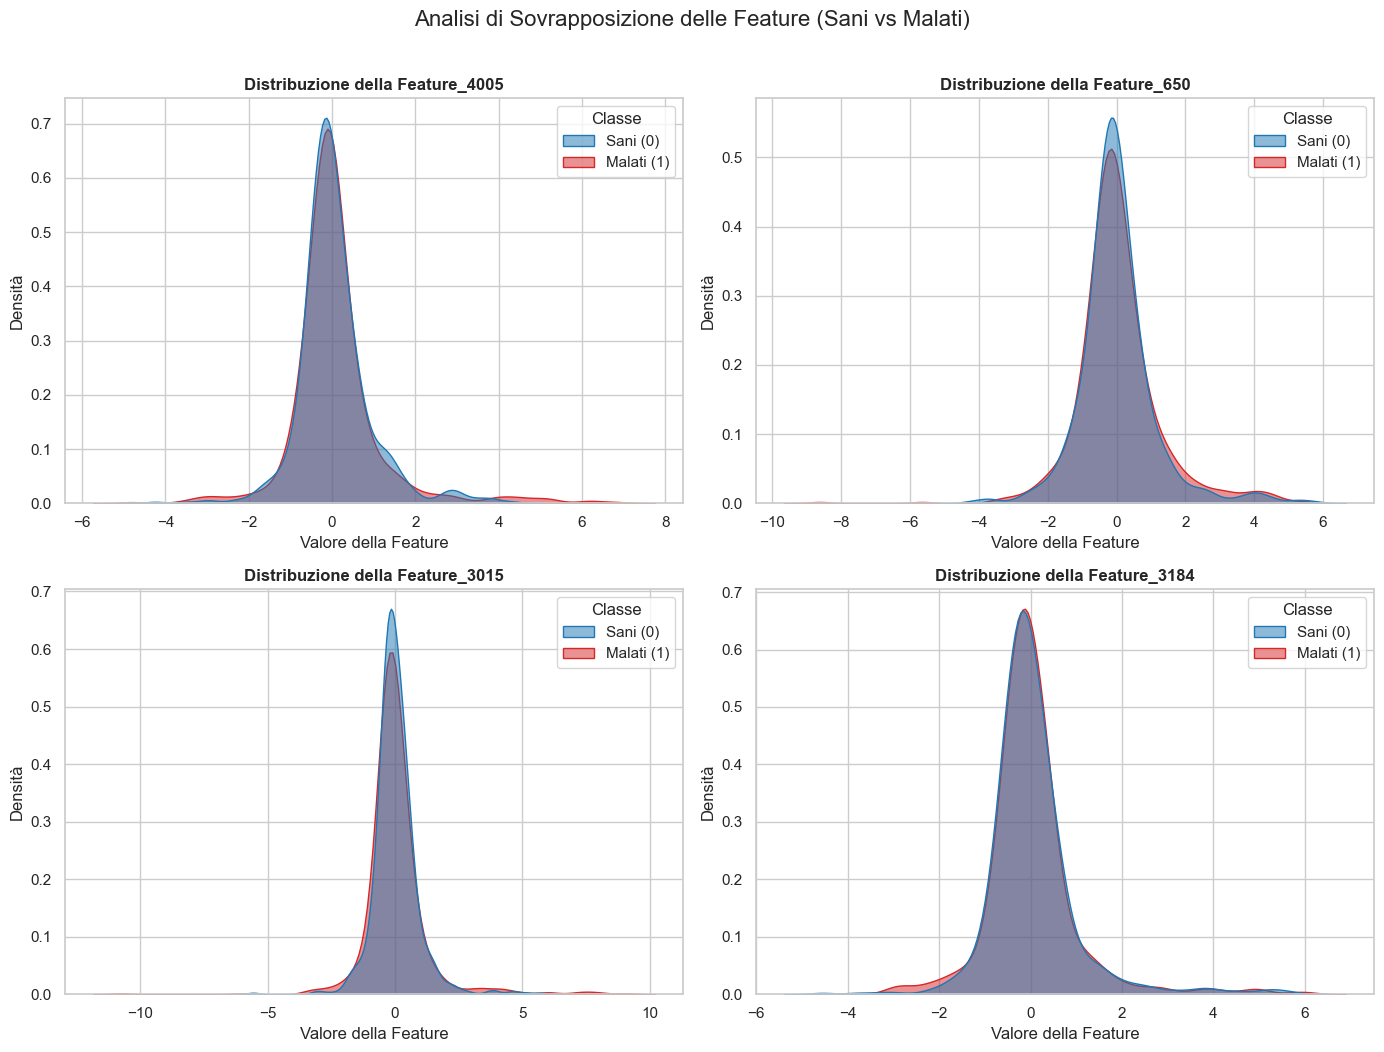

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- 1. PREPARAZIONE DEI DATI ---
# Siccome un ECG ha migliaia di feature (punti del tracciato), non possiamo stamparle tutte.
# Ne scegliamo 4 a caso o le 4 che ritieni più importanti per fare il grafico.
indici_features = np.random.choice(f0.shape[0], size=4, replace=False)
#indici_features = [1700, 4673, 5329, 6489] # Cambia questi numeri per esplorare punti diversi dell'ECG

# Creiamo un DataFrame Pandas al volo (Seaborn lo adora)
df = pd.DataFrame(data[:, indici_features], columns=[f'Feature_{i}' for i in indici_features])

# Aggiungiamo la colonna delle etichette e la trasformiamo in testo per la legenda
df['Classe'] = labels.ravel()
df['Classe'] = df['Classe'].map({0.0: 'Sani (0)', 1.0: 'Malati (1)'})

# --- 2. CREAZIONE DEL GRAFICO A GRIGLIA ---
sns.set_theme(style="whitegrid") # Dà un look molto pulito e professionale al grafico

# Creiamo una figura con 4 grafici (2 righe, 2 colonne)
fig, assi = plt.subplots(2, 2, figsize=(14, 10))
assi = assi.ravel() # Appiattisce la matrice 2x2 in un array di 4 elementi per fare il ciclo più facilmente

# --- 3. DISEGNIAMO LE DISTRIBUZIONI ---
for i, colonna in enumerate(df.columns[:-1]): # Escludiamo l'ultima colonna che è 'Classe'
    
    # KDE Plot: Disegna le curve di densità sovrapposte
    sns.kdeplot(
        data=df, 
        x=colonna, 
        hue='Classe',       # Separa i colori in base a Sani/Malati
        fill=True,          # Colora l'interno delle curve
        common_norm=False,  # FONDAMENTALE se le classi sono sbilanciate (normalizza le curve separatamente)
        palette=['#1f77b4', '#d62728'], # Blu per sani, Rosso per malati
        alpha=0.5,          # Trasparenza per far vedere la sovrapposizione
        ax=assi[i]          # Dice a Seaborn in quale riquadro disegnare
    )
    
    assi[i].set_title(f'Distribuzione della {colonna}', fontsize=12, fontweight='bold')
    assi[i].set_xlabel("Valore della Feature")
    assi[i].set_ylabel("Densità")

# Regola gli spazi per non far accavallare i testi
plt.tight_layout()
plt.suptitle("Analisi di Sovrapposizione delle Feature (Sani vs Malati)", fontsize=16, y=1.05)
plt.show()